# Imports

In [220]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal

from bciflow.datasets.cbcic import cbcic
from bciflow.datasets.bciciv2a import bciciv2a
from bciflow.datasets.bciciv2b import bciciv2b

from methods.bandpass import bandpass_conv, bandpass_conv_kernel

# Configurações

In [221]:
datasets_cfg = {
    "2a": {"maxSubjects": 9},
    # "2b": {"maxSubjects": 9},
    # "cbcic": {"maxSubjects": 10},
}

subject = 1

datasets

In [222]:
dataset_name = "2a"

if dataset_name == "cbcic":
    dataset = cbcic
    path = "C:/Users/Hychiro/Documents/Ufjf/bci/testes no codigo do bciflow/Data/CBCIC"

elif dataset_name == "2a":
    dataset = bciciv2a
    path = "C:/Users/Hychiro/Documents/Ufjf/bci/testes no codigo do bciflow/Data/2a"

elif dataset_name == "2b":
    dataset = bciciv2b
    path = "C:/Users/Hychiro/Documents/Ufjf/bci/testes no codigo do bciflow/Data/2b"

data = dataset(
    subject=subject,
    path=path,
    labels=["left-hand", "right-hand"]
)

corta janelas

In [223]:
cue = data["events"]["cue"][0]

start = int((cue + 0.5) * data["sfreq"])
finish = int((cue + 2.5) * data["sfreq"])

if len(data["X"].shape) == 4:
    data["X"] = data["X"][:, :, :, start:finish]
else:
    data["X"] = data["X"][:, :, start:finish]

print(data["X"].shape)
print(data["sfreq"])

(288, 1, 22, 500)
250.0


# Espectrogramas

## codigo dos sinais

original

In [224]:
f, t, Sxx1 = signal.spectrogram(
    data["X"][0,0,0],
    fs=data["sfreq"],
    nperseg=int(data["sfreq"]/4)
)

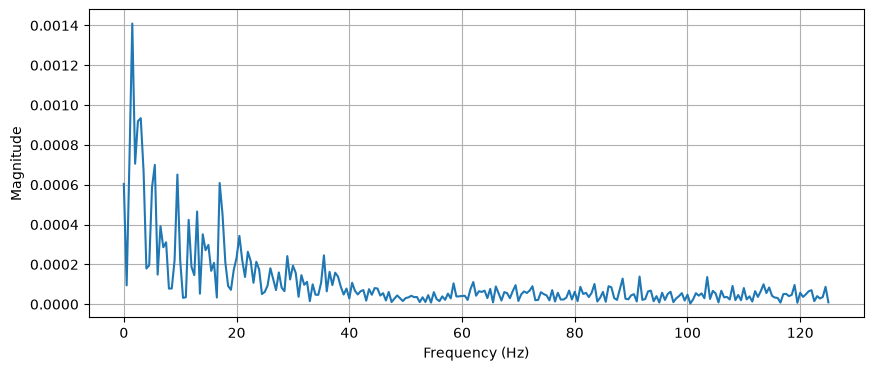

In [225]:
freq = np.fft.rfftfreq(len(data["X"][0,0,0]), 1/data["sfreq"])
Y = np.fft.rfft(data["X"][0,0,0])

plt.figure(figsize=(10,4))
plt.plot(freq, np.abs(Y))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

filtro por convolução de janela de hamming

In [226]:
eegdata1 = data.copy()

bandpass_filtered_data = bandpass_conv(
    eegdata1,
    low_cut=4,
    high_cut=40
)

f, t, Sxx2 = signal.spectrogram(
    bandpass_filtered_data["X"][0,0,0],
    fs=bandpass_filtered_data["sfreq"],
    nperseg=int(bandpass_filtered_data["sfreq"]/4)
)

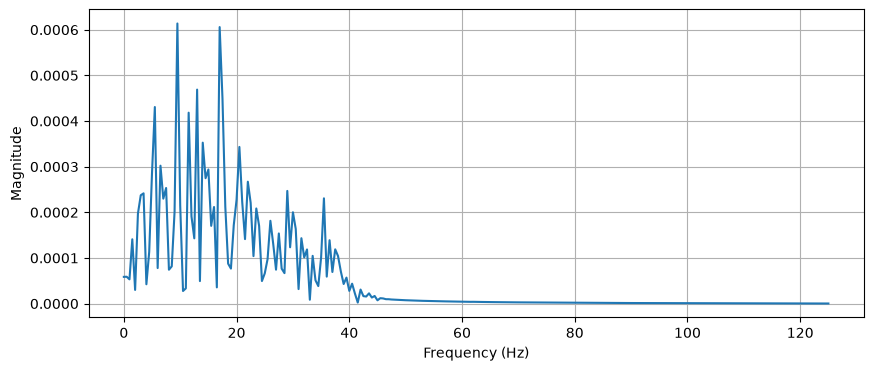

In [227]:
freq = np.fft.rfftfreq(len(bandpass_filtered_data["X"][0,0,0]), 1/bandpass_filtered_data["sfreq"])
Y = np.fft.rfft(bandpass_filtered_data["X"][0,0,0])

plt.figure(figsize=(10,4))
plt.plot(freq, np.abs(Y))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

Kernel obtido do Safka

In [228]:
path = "C:/Users/Hychiro/Documents/Mestrado/Tese de Mestrado/Safka/results/tables_and_graphs/best_kernels/"

filename = path + f"{dataset_name}_safka_csp_kernel_data.csv"

df = pd.read_csv(filename)

kernel = (
    df["best_kernels"][df["subject"] == subject]
    .to_list()[0]
    .strip("[]")
    .replace("\n", "")
    .replace("  ", " ")
)

kernel = np.fromstring(kernel[1:-1], sep=" ", dtype=float)

print(kernel.shape)

(65,)


In [229]:
eegdata2 = data.copy()

bandpass_filtered_data2 = bandpass_conv_kernel(
    eegdata2,
    kernel=kernel
)

f, t, Sxx3 = signal.spectrogram(
    bandpass_filtered_data2["X"][0,0,0],
    fs=bandpass_filtered_data2["sfreq"],
    nperseg=int(bandpass_filtered_data2["sfreq"]/4)
)

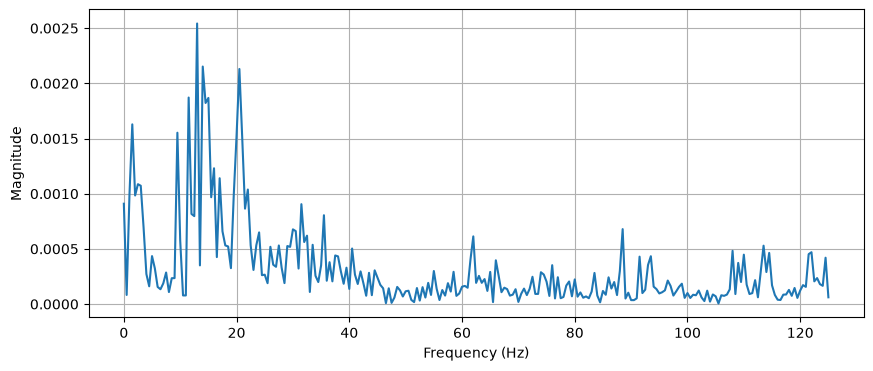

In [230]:
freq = np.fft.rfftfreq(len(bandpass_filtered_data2["X"][0,0,0]), 1/bandpass_filtered_data2["sfreq"])
Y = np.fft.rfft(bandpass_filtered_data2["X"][0,0,0])

plt.figure(figsize=(10,4))
plt.plot(freq, np.abs(Y))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

## Resultado grafico

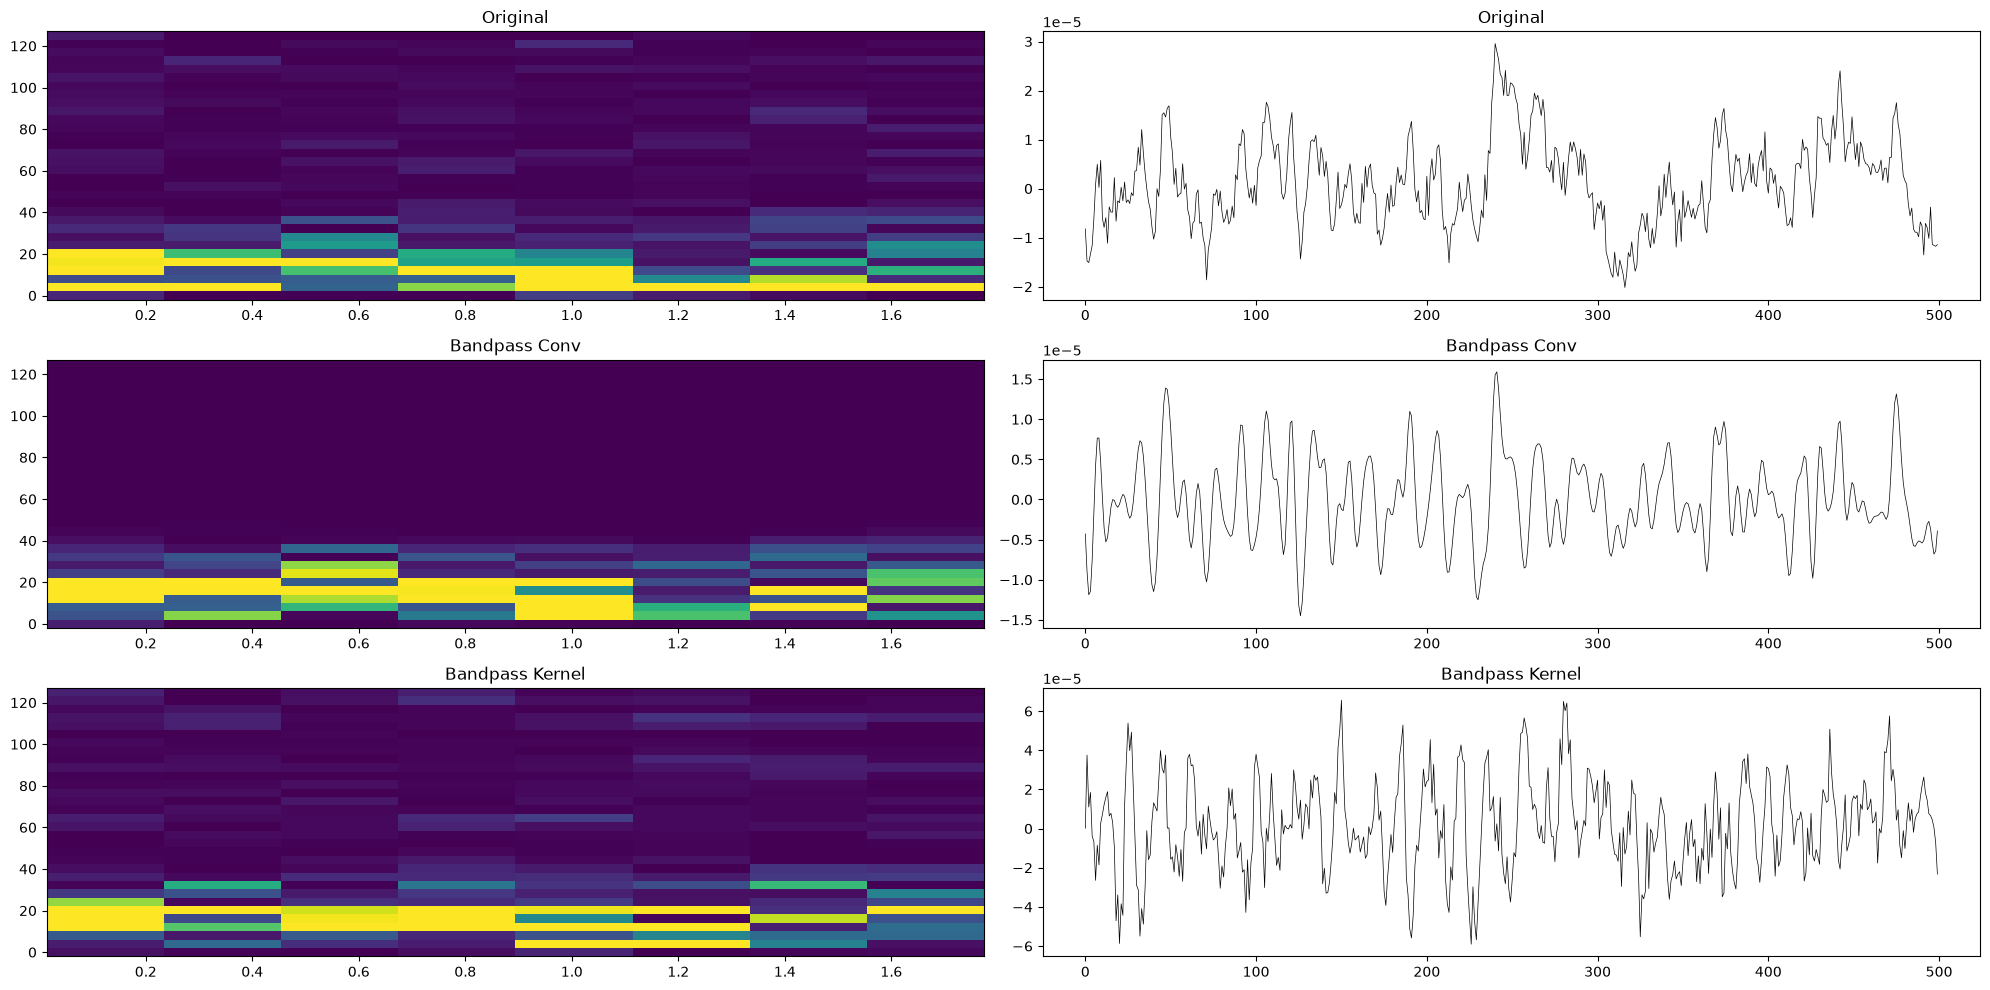

In [231]:
fig, axs = plt.subplots(3,2, figsize=(20,10))

axs[0,0].pcolormesh(
    t,
    f,
    Sxx1,
    vmin=np.percentile(Sxx1,5),
    vmax=np.percentile(Sxx1,95)
)

axs[0,0].set_title("Original")

axs[1,0].pcolormesh(
    t,
    f,
    Sxx2,
    vmin=np.percentile(Sxx2,5),
    vmax=np.percentile(Sxx2,95)
)

axs[1,0].set_title("Bandpass Conv")

axs[2,0].pcolormesh(
    t,
    f,
    Sxx3,
    vmin=np.percentile(Sxx3,5),
    vmax=np.percentile(Sxx3,95)
)

axs[2,0].set_title("Bandpass Kernel")

axs[0,1].plot(data["X"][0,0,0], c="k", linewidth=.5)
axs[1,1].plot(bandpass_filtered_data["X"][0,0,0], c="k", linewidth=.5)
axs[2,1].plot(bandpass_filtered_data2["X"][0,0,0], c="k", linewidth=.5)

axs[0,1].set_title("Original")
axs[1,1].set_title("Bandpass Conv")
axs[2,1].set_title("Bandpass Kernel")

plt.tight_layout()
plt.show()

## Interpretação do kernel do safka

### Resposta em frequência

OBS: Esse é o gráfico mais utilizado em processamento digital de sinais para verificar um filtro.

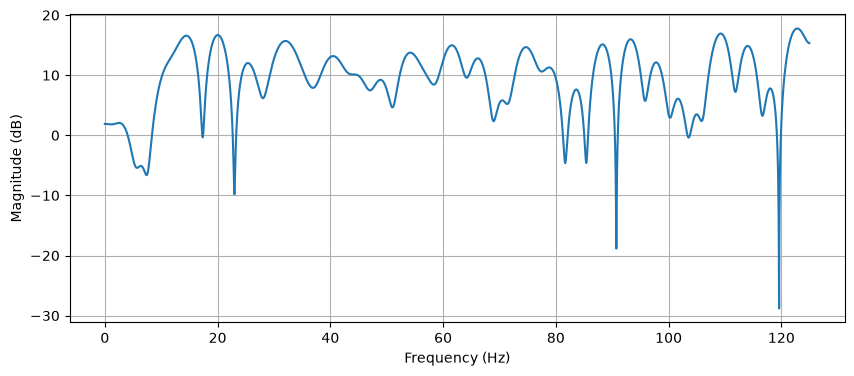

In [232]:
def plot_kernel_frequency_response(kernel, data): 
    w, H = signal.freqz(kernel, worN=4096, fs=data["sfreq"])

    plt.figure(figsize=(10,4))

    plt.plot(w, 20*np.log10(np.abs(H)+1e-12))

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)

    plt.show()

plot_kernel_frequency_response(kernel, data)

### FFT do kernel

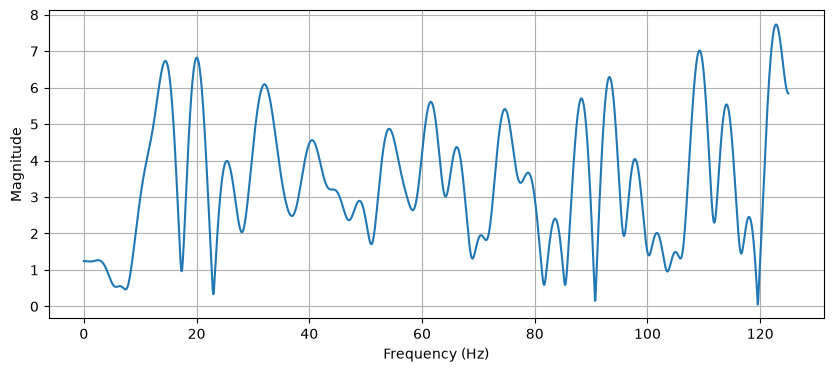

In [233]:
def plot_kernel_frequency_response_fft(kernel, data):
    H = np.fft.rfft(kernel, 4096)

    freq = np.fft.rfftfreq(4096, 1/data["sfreq"])

    plt.figure(figsize=(10,4))

    plt.plot(freq, np.abs(H))

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")

    plt.grid(True)

    plt.show()

plot_kernel_frequency_response_fft(kernel, data)

### Quais frequências possuem pelo menos metade da potência máxima

In [234]:
def print_kernel_frequency_response_stats(kernel, data):   
    H = np.fft.rfft(kernel, 4096) 
    freq = np.fft.rfftfreq(4096, 1/data["sfreq"])
    gain_db = 20*np.log10(np.abs(H)+1e-12)
    print(f"Max gain: {gain_db.max():.2f} dB at {freq[gain_db.argmax()]:.2f} Hz")
    print(f"Min gain: {gain_db.min():.2f} dB at {freq[gain_db.argmin()]:.2f} Hz")
    print(f"Mean gain: {np.median(gain_db):.2f} dB")
    print(f"Number of samples: {len(gain_db)}")
    # all frequencies where gain is above mean gain
    mask = gain_db >= np.median(gain_db)
    print(f"Number of frequencies above mean gain: {np.sum(mask)}")
    # all bands of this kernel print intervals
    flag = False
    print("Frequency bands where gain is above mean gain:")
    print(f"length of mask: {len(mask)}")
    for i in range(len(mask)-1):
        if flag == False and mask[i] == True:
            start = freq[i]
            flag = True
        if flag == True and mask[i] == False:
            end = freq[i-1]
            flag = False
            print(f"Band: {start:.2f} Hz - {end:.2f} Hz")

print_kernel_frequency_response_stats(kernel, data)

Max gain: 17.77 dB at 122.80 Hz
Min gain: -25.64 dB at 119.57 Hz
Mean gain: 10.23 dB
Number of samples: 2049
Number of frequencies above mean gain: 1025
Frequency bands where gain is above mean gain:
length of mask: 2049
Band: 10.31 Hz - 16.48 Hz
Band: 18.19 Hz - 21.97 Hz
Band: 24.35 Hz - 26.55 Hz
Band: 29.36 Hz - 35.34 Hz
Band: 38.39 Hz - 43.33 Hz
Band: 52.37 Hz - 56.88 Hz
Band: 59.33 Hz - 63.72 Hz
Band: 64.70 Hz - 67.44 Hz
Band: 72.75 Hz - 79.71 Hz
Band: 86.67 Hz - 89.78 Hz
Band: 91.61 Hz - 95.03 Hz
Band: 96.86 Hz - 98.75 Hz
Band: 107.12 Hz - 111.21 Hz
Band: 112.49 Hz - 115.54 Hz


## Interpretação multikernel safka

### metodos

In [235]:
def signal_frequency_magnitude(signal, data):
    freq = np.fft.rfftfreq(len(signal), 1/data["sfreq"])
    Y = np.fft.rfft(signal)

    plt.figure(figsize=(10,4))
    plt.plot(freq, np.abs(Y))
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.show()

def process_kernels(kernels, data):
    final_data = []
    for each in kernels:
        aux_data = data.copy()

        kernel_filtered_data = bandpass_conv_kernel(
            aux_data,
            kernel=each
        )

        f, t, Sxx_result = signal.spectrogram(
            kernel_filtered_data["X"][0,0,0],
            fs=kernel_filtered_data["sfreq"],
            nperseg=int(kernel_filtered_data["sfreq"]/4)
        )
        final_data.append((t,f,Sxx_result,kernel_filtered_data["X"][0,0,0]))
    return final_data

def plot_end_results(kernels,data):
    len_kernel = len(kernels)
    final_data = process_kernels(kernels, data)
    fig, axs = plt.subplots(len_kernel+1,2, figsize=(30,20))
    f, t, Sxx_result = signal.spectrogram(
            data["X"][0,0,0],
            fs=data["sfreq"],
            nperseg=int(data["sfreq"]/4)
        )
    axs[0,0].pcolormesh(
            t,
            f,
            Sxx_result,
            vmin=np.percentile(Sxx1,5),
            vmax=np.percentile(Sxx1,95)
        )
    axs[0,0].set_title("Original")

    axs[0,1].plot(data["X"][0,0,0], c="k", linewidth=.5)
    axs[0,1].set_title("Original")
    
    for i in range(len(final_data)):
        # print(final_data[i][0])
        # print(final_data[i][1])
        # print(final_data[i][2].shape)
        # print(final_data[i][3].shape)

        axs[i+1,0].pcolormesh(
            final_data[i][0],
            final_data[i][1],
            final_data[i][2],
            vmin=np.percentile(Sxx1,5),
            vmax=np.percentile(Sxx1,95)
        )
        axs[i+1,0].set_title(f"Kernel {i+1}")
        axs[i+1,1].plot(final_data[i][3], c="k", linewidth=.5)
        axs[i+1,1].set_title(f"Kernel {i+1}")

### Carregando Kernel

In [236]:
path = "C:/Users/Hychiro/Documents/Mestrado/Tese de Mestrado/Safka/results/tables_and_graphs/best_kernels/"

filename = path + f"{dataset_name}_multikernel_safka_csp_kernel_data.csv"

df = pd.read_csv(filename)

kernel = (
    df["best_kernels"][df["subject"] == subject]
    .to_list()[0]
    .replace("\n", "")
    .replace("  ", " ")
    .replace("] [", "],[")
)

kernel = kernel[1:-1]
kernel = kernel.split(",")
print(f"Number of kernels: {len(kernel)}")
print(f"Kernel string: {kernel[0]}")


final_kernels = []
for each in kernel:
    each = each.strip("[]")
    each = np.fromstring(each, sep=" ", dtype=float)
    print(f"Kernel shape: {each.shape}")
    final_kernels.append(each)
    
final_kernels = np.array(final_kernels)
print(f"Final kernels shape: {final_kernels.shape}")
print(f"Final kernels: {final_kernels[0]}")
print(f"type of final kernels: {type(final_kernels)}")

Number of kernels: 9
Kernel string: [-1.86374966e-02 -7.41745648e-03 3.04518109e-03 2.03931810e-02 -4.18584243e-01 -4.00815501e-01 -2.21882840e-04 -4.03670211e-02 -1.85304185e-02 -1.82977737e-02 1.38070149e-02 9.59866821e-02  1.55210580e-02 1.38855609e-01 6.11495827e-02 -2.56247921e-01  3.25935731e-01 -4.32518278e-02 1.17579037e-03 -3.87732862e-03 -1.55665477e-01 -3.25153323e-02 7.38276819e-03 -2.06289542e-02 -1.82403647e-01 -2.38238408e-03 1.32726034e-01 -3.66187523e-05  2.48407804e-01 1.76091291e-03 1.05113100e-02 -8.41832183e-03  9.21638722e-04 -6.89369297e-02 4.69304832e-02 1.39676349e-02 -3.66187129e-02 -3.21804368e-03 -5.90558197e-02 1.22487747e-02  3.09880155e-04 5.34207986e-06 1.10092050e-03 -1.11965282e-03  1.73838587e-02 3.53499962e-05 4.66805791e-03 -3.33399929e-03  1.50918570e-03 8.31232695e-04 1.98373319e-01 4.37803513e-03 -8.10423952e-01 -2.10909668e-02 -8.09155811e-03 -5.38880205e-01 -5.29710395e-03 6.56333754e-04 -2.06151094e-04 1.07224467e-02 -3.08318237e-02 -8.3813332

### Results

#### Resposta em frequência

OBS: Esse é o gráfico mais utilizado em processamento digital de sinais para verificar um filtro.

Kernel 1


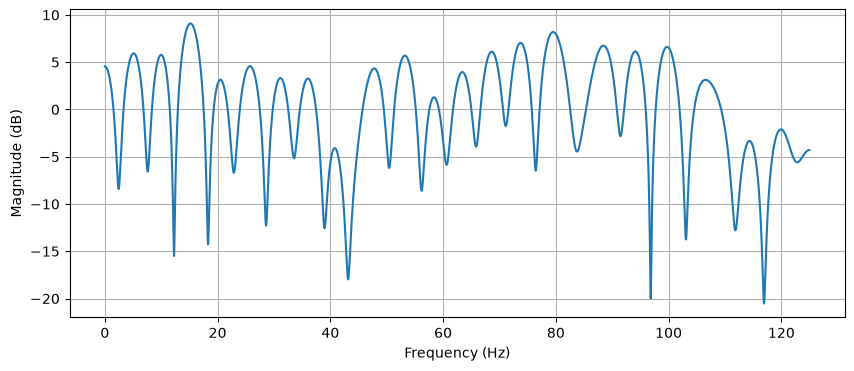

Kernel 2


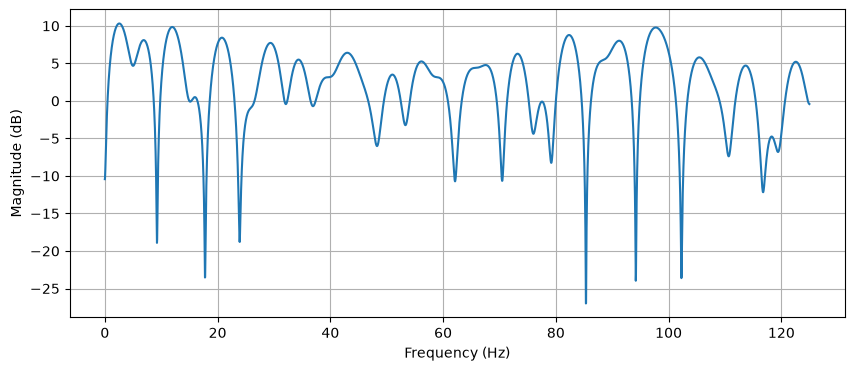

Kernel 3


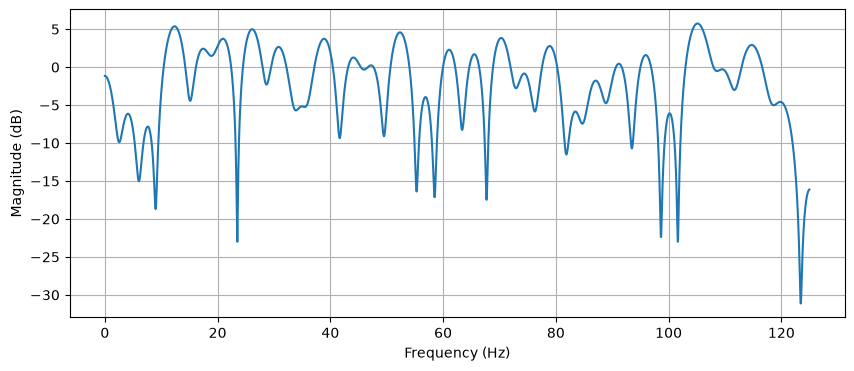

Kernel 4


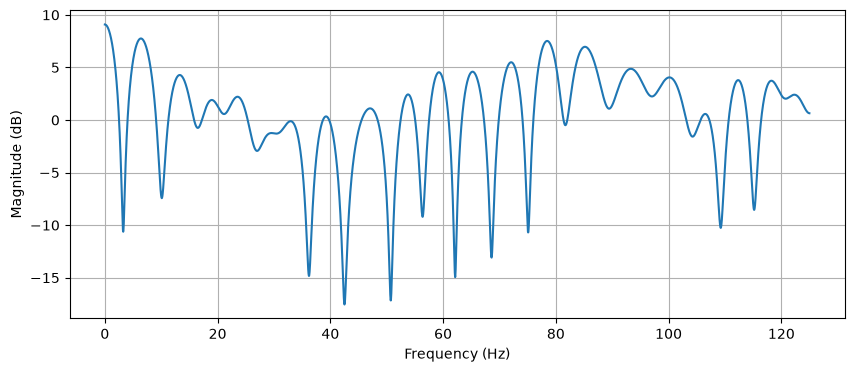

Kernel 5


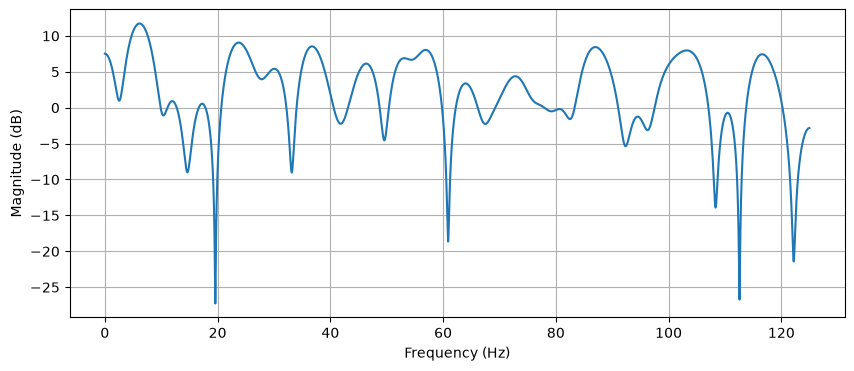

Kernel 6


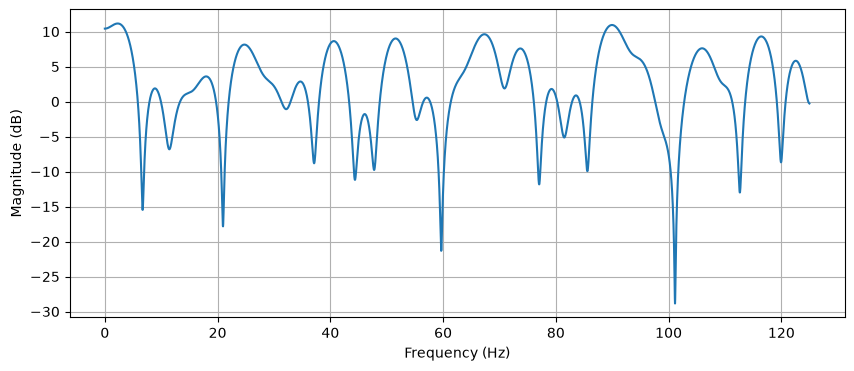

Kernel 7


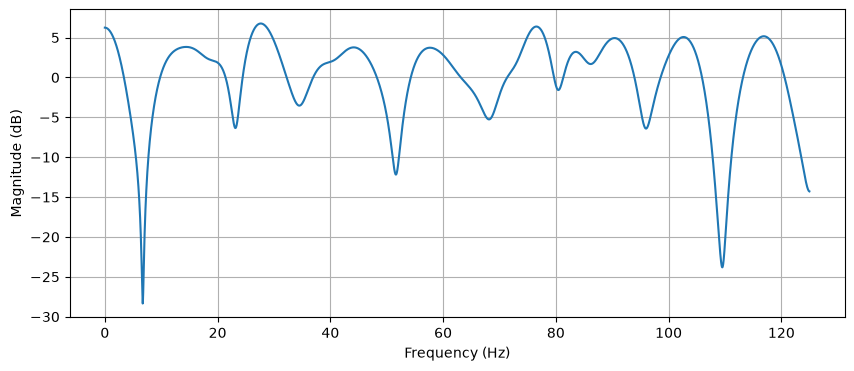

Kernel 8


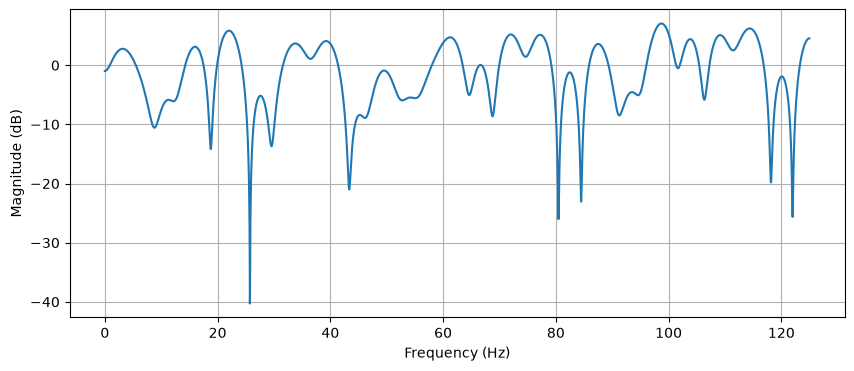

Kernel 9


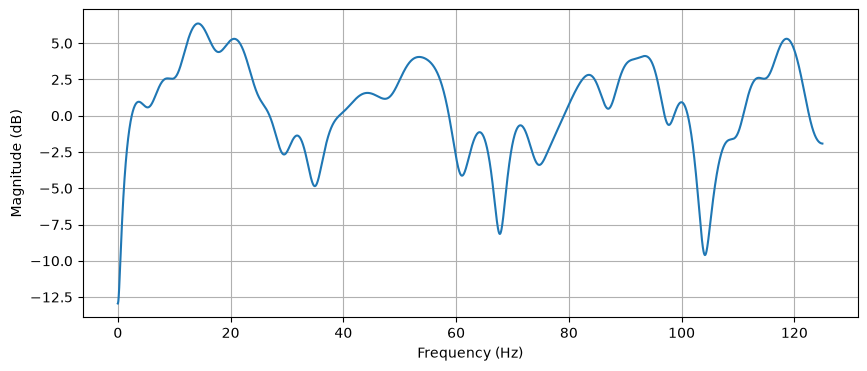

In [237]:
contador = 1
for each in final_kernels:
    print(f"Kernel {contador}" )
    plot_kernel_frequency_response(each,data)
    contador = contador + 1


#### FFT do kernel

Kernel 1


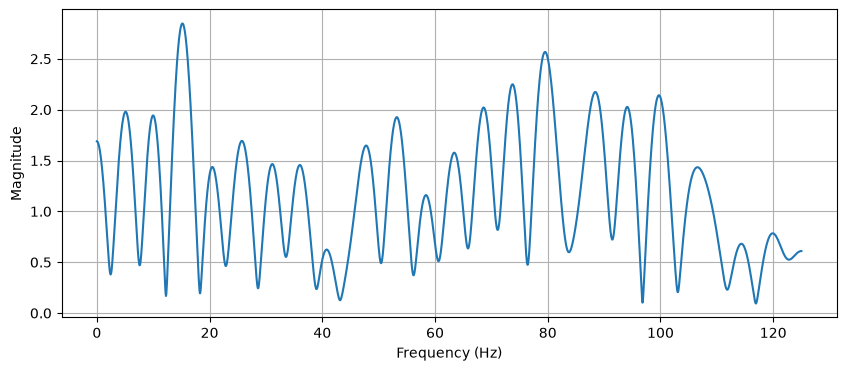

Kernel 2


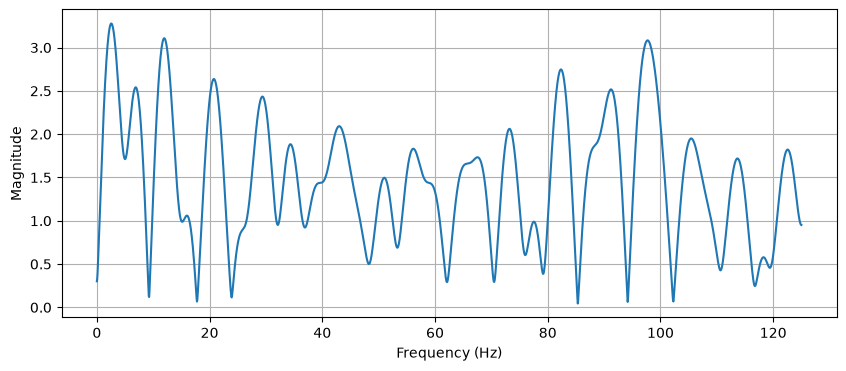

Kernel 3


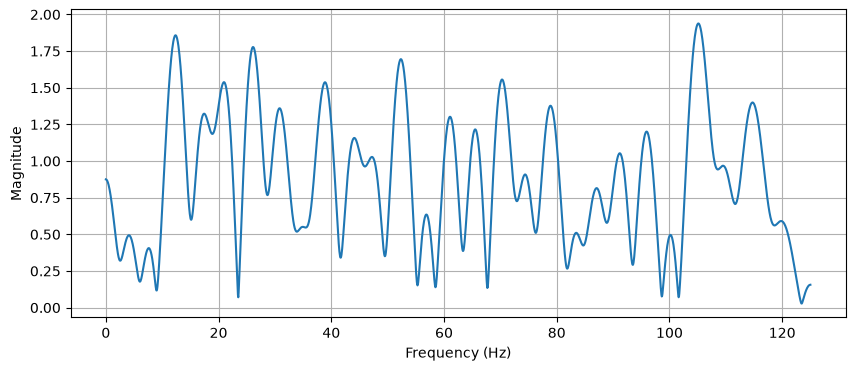

Kernel 4


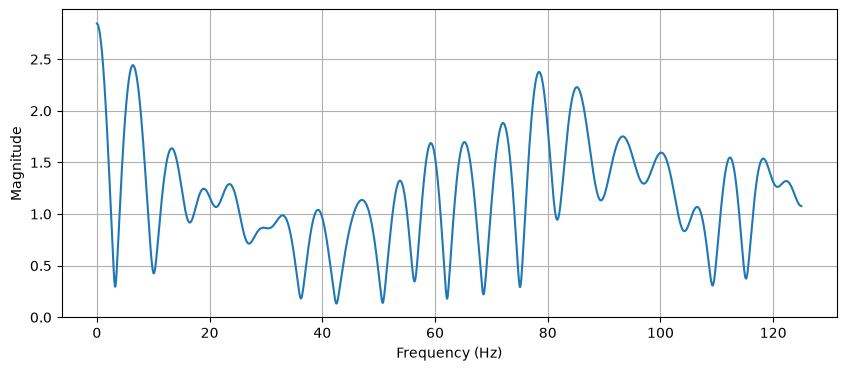

Kernel 5


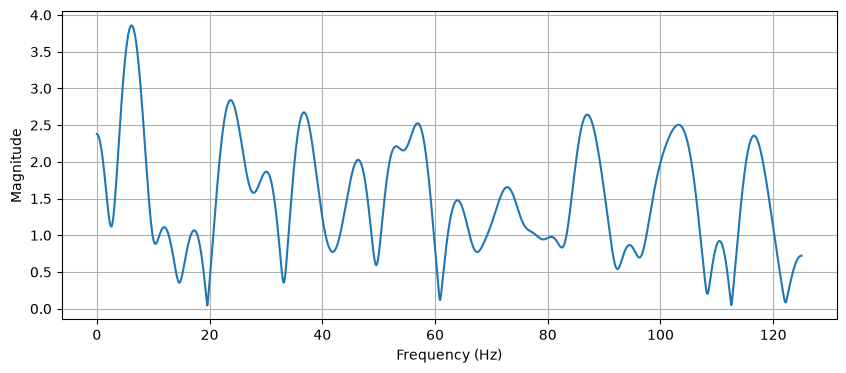

Kernel 6


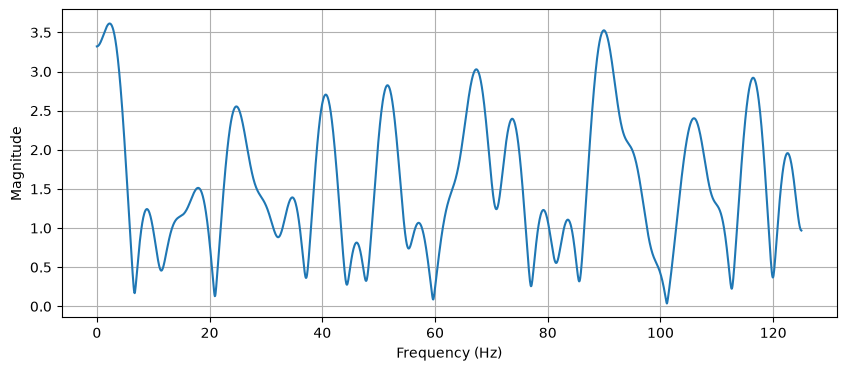

Kernel 7


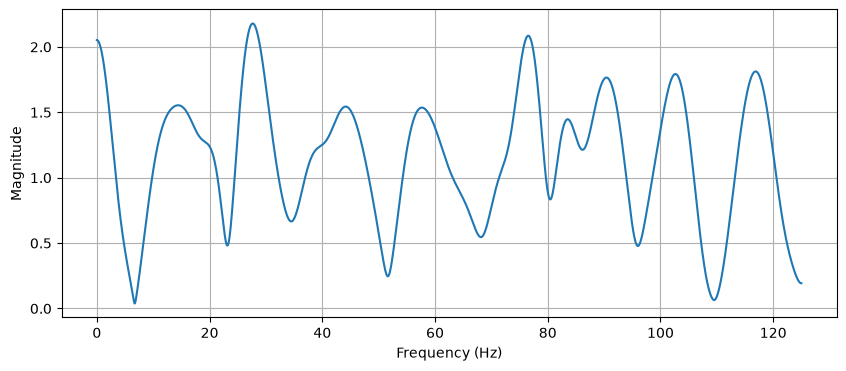

Kernel 8


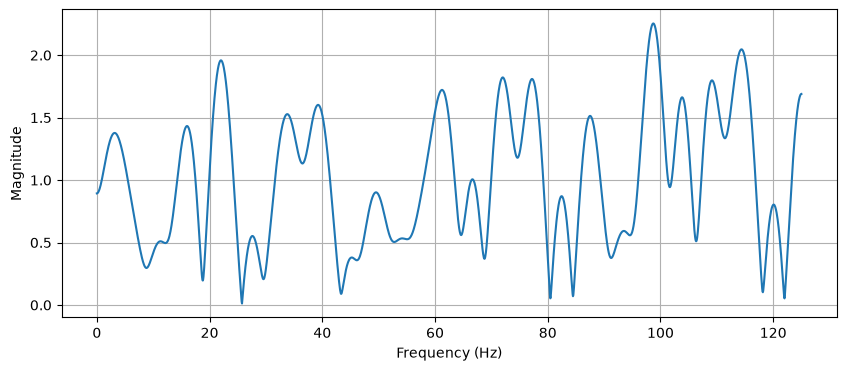

Kernel 9


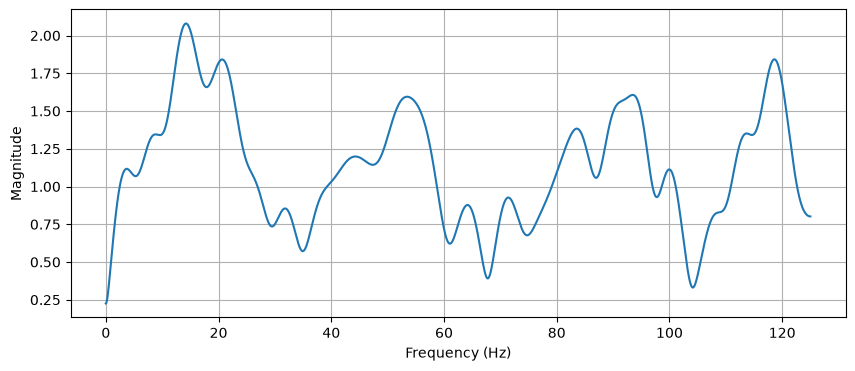

In [238]:
contador = 1
for each in final_kernels:
    print(f"Kernel {contador}" )
    plot_kernel_frequency_response_fft(each,data)
    contador = contador + 1

#### Quais frequências possuem pelo menos metade da potência máxima

In [239]:
contador = 1
for each in final_kernels:
    print(f"Kernel {contador}" )
    print_kernel_frequency_response_stats(each,data)
    contador = contador + 1


Kernel 1
Max gain: 9.09 dB at 15.20 Hz
Min gain: -20.52 dB at 116.94 Hz
Mean gain: 0.92 dB
Number of samples: 2049
Number of frequencies above mean gain: 1025
Frequency bands where gain is above mean gain:
length of mask: 2049
Band: 0.00 Hz - 1.34 Hz
Band: 3.48 Hz - 6.71 Hz
Band: 8.48 Hz - 11.41 Hz
Band: 13.06 Hz - 17.40 Hz
Band: 19.53 Hz - 21.55 Hz
Band: 24.17 Hz - 27.28 Hz
Band: 29.97 Hz - 32.29 Hz
Band: 34.85 Hz - 37.23 Hz
Band: 45.96 Hz - 49.32 Hz
Band: 51.45 Hz - 54.99 Hz
Band: 57.98 Hz - 58.84 Hz
Band: 61.95 Hz - 64.82 Hz
Band: 66.77 Hz - 70.43 Hz
Band: 71.78 Hz - 75.62 Hz
Band: 77.27 Hz - 82.34 Hz
Band: 85.63 Hz - 90.64 Hz
Band: 92.29 Hz - 95.76 Hz
Band: 97.84 Hz - 101.81 Hz
Band: 104.80 Hz - 108.89 Hz
Kernel 2
Max gain: 10.31 dB at 2.56 Hz
Min gain: -27.00 dB at 85.33 Hz
Mean gain: 3.25 dB
Number of samples: 2049
Number of frequencies above mean gain: 1025
Frequency bands where gain is above mean gain:
length of mask: 2049
Band: 0.73 Hz - 8.36 Hz
Band: 10.13 Hz - 14.16 Hz
Band:

#### Magnitude do sinal processado em frequencia

9
Kernel 1


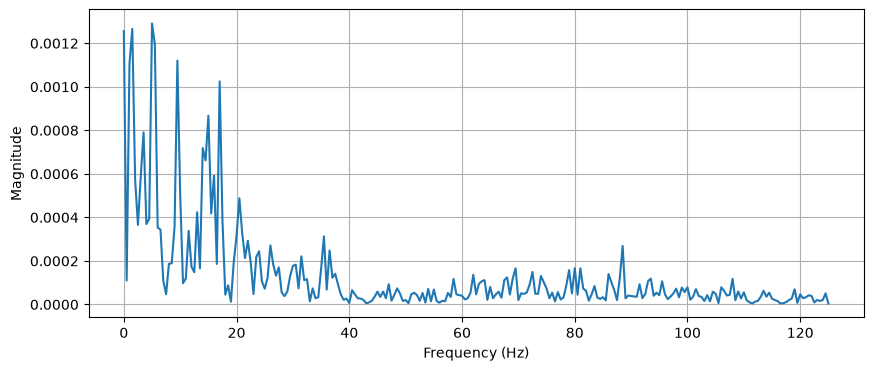

Kernel 2


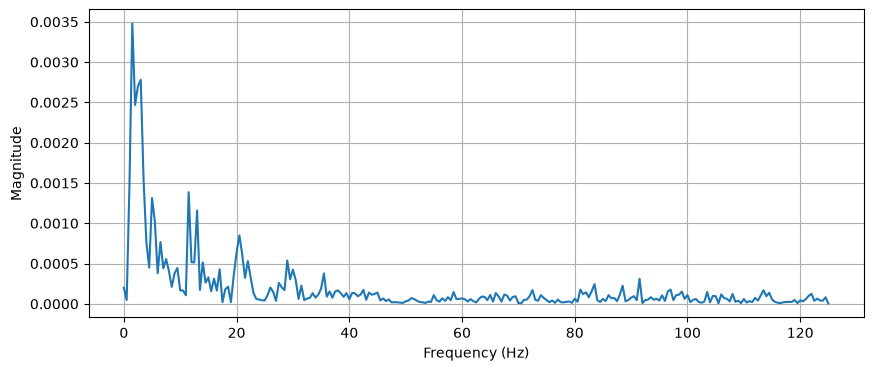

Kernel 3


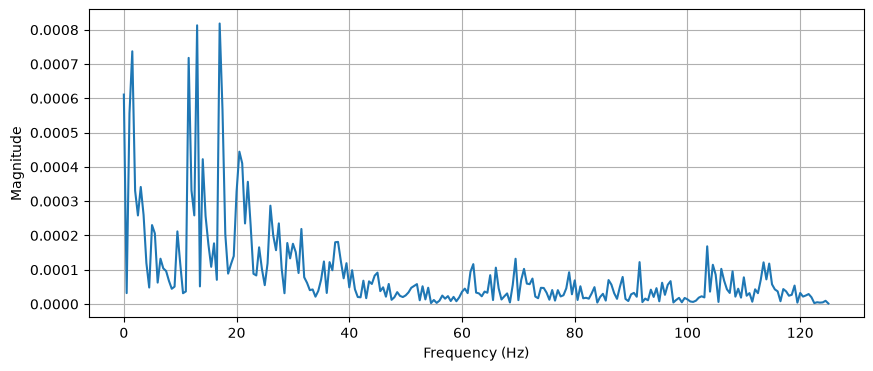

Kernel 4


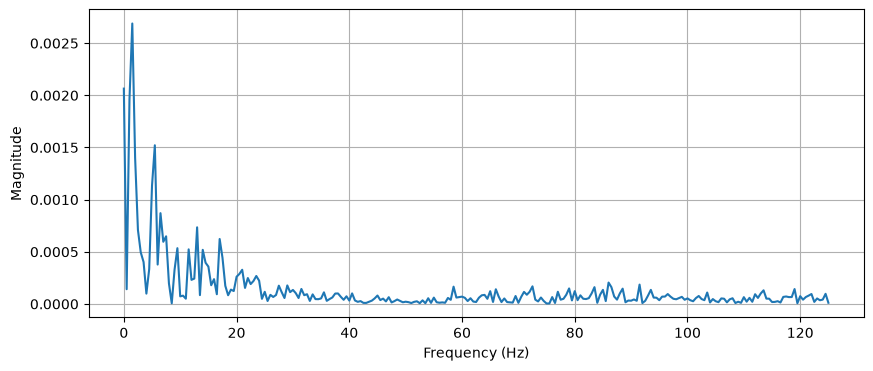

Kernel 5


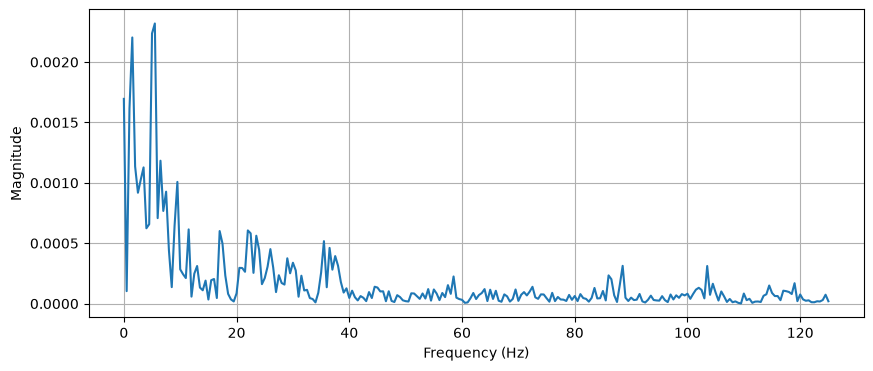

Kernel 6


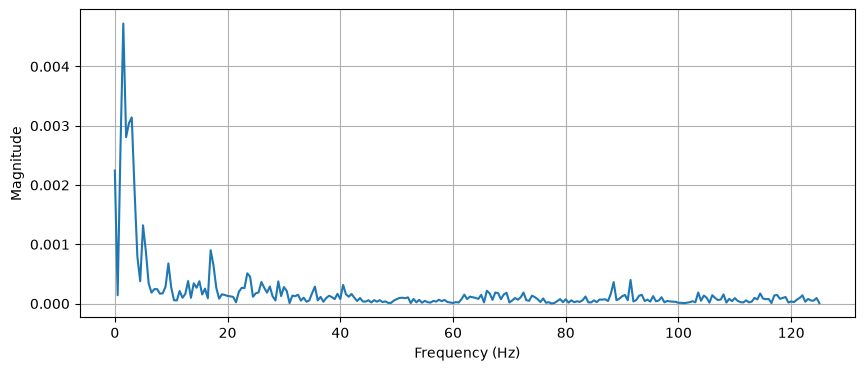

Kernel 7


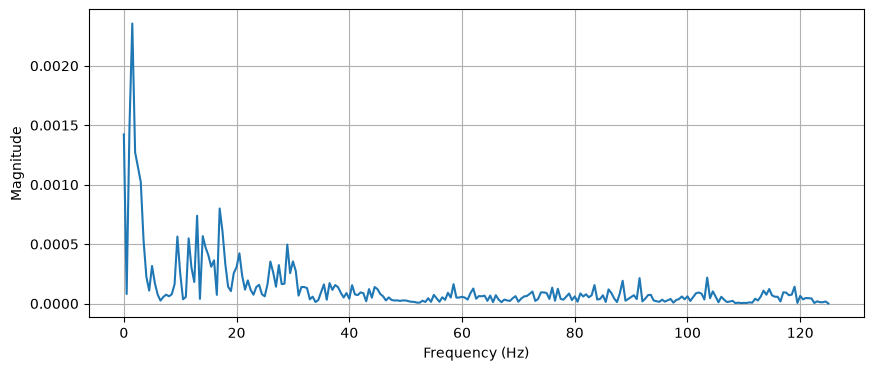

Kernel 8


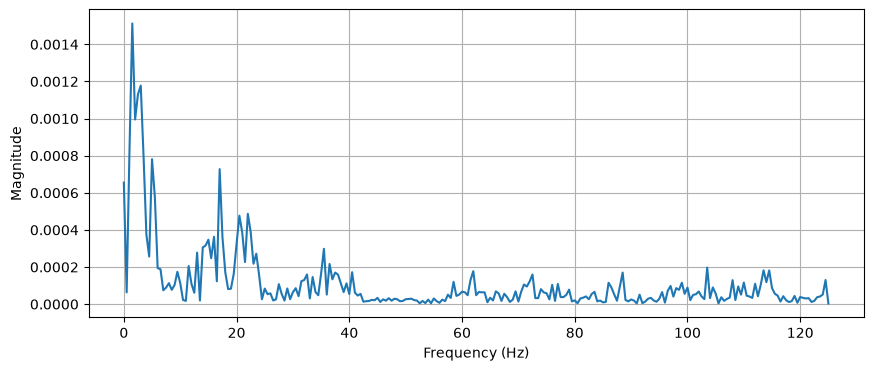

Kernel 9


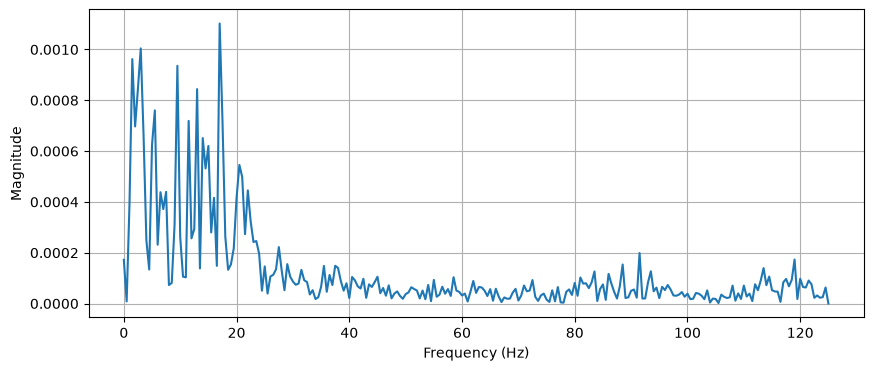

In [240]:
contador = 1
final_data_kernels = process_kernels(final_kernels,data)
print(len(final_data_kernels))
for each in final_data_kernels:
    print(f"Kernel {contador}" )
    signal_frequency_magnitude(each[3],data)
    contador = contador + 1

#### Comparando resultados finais

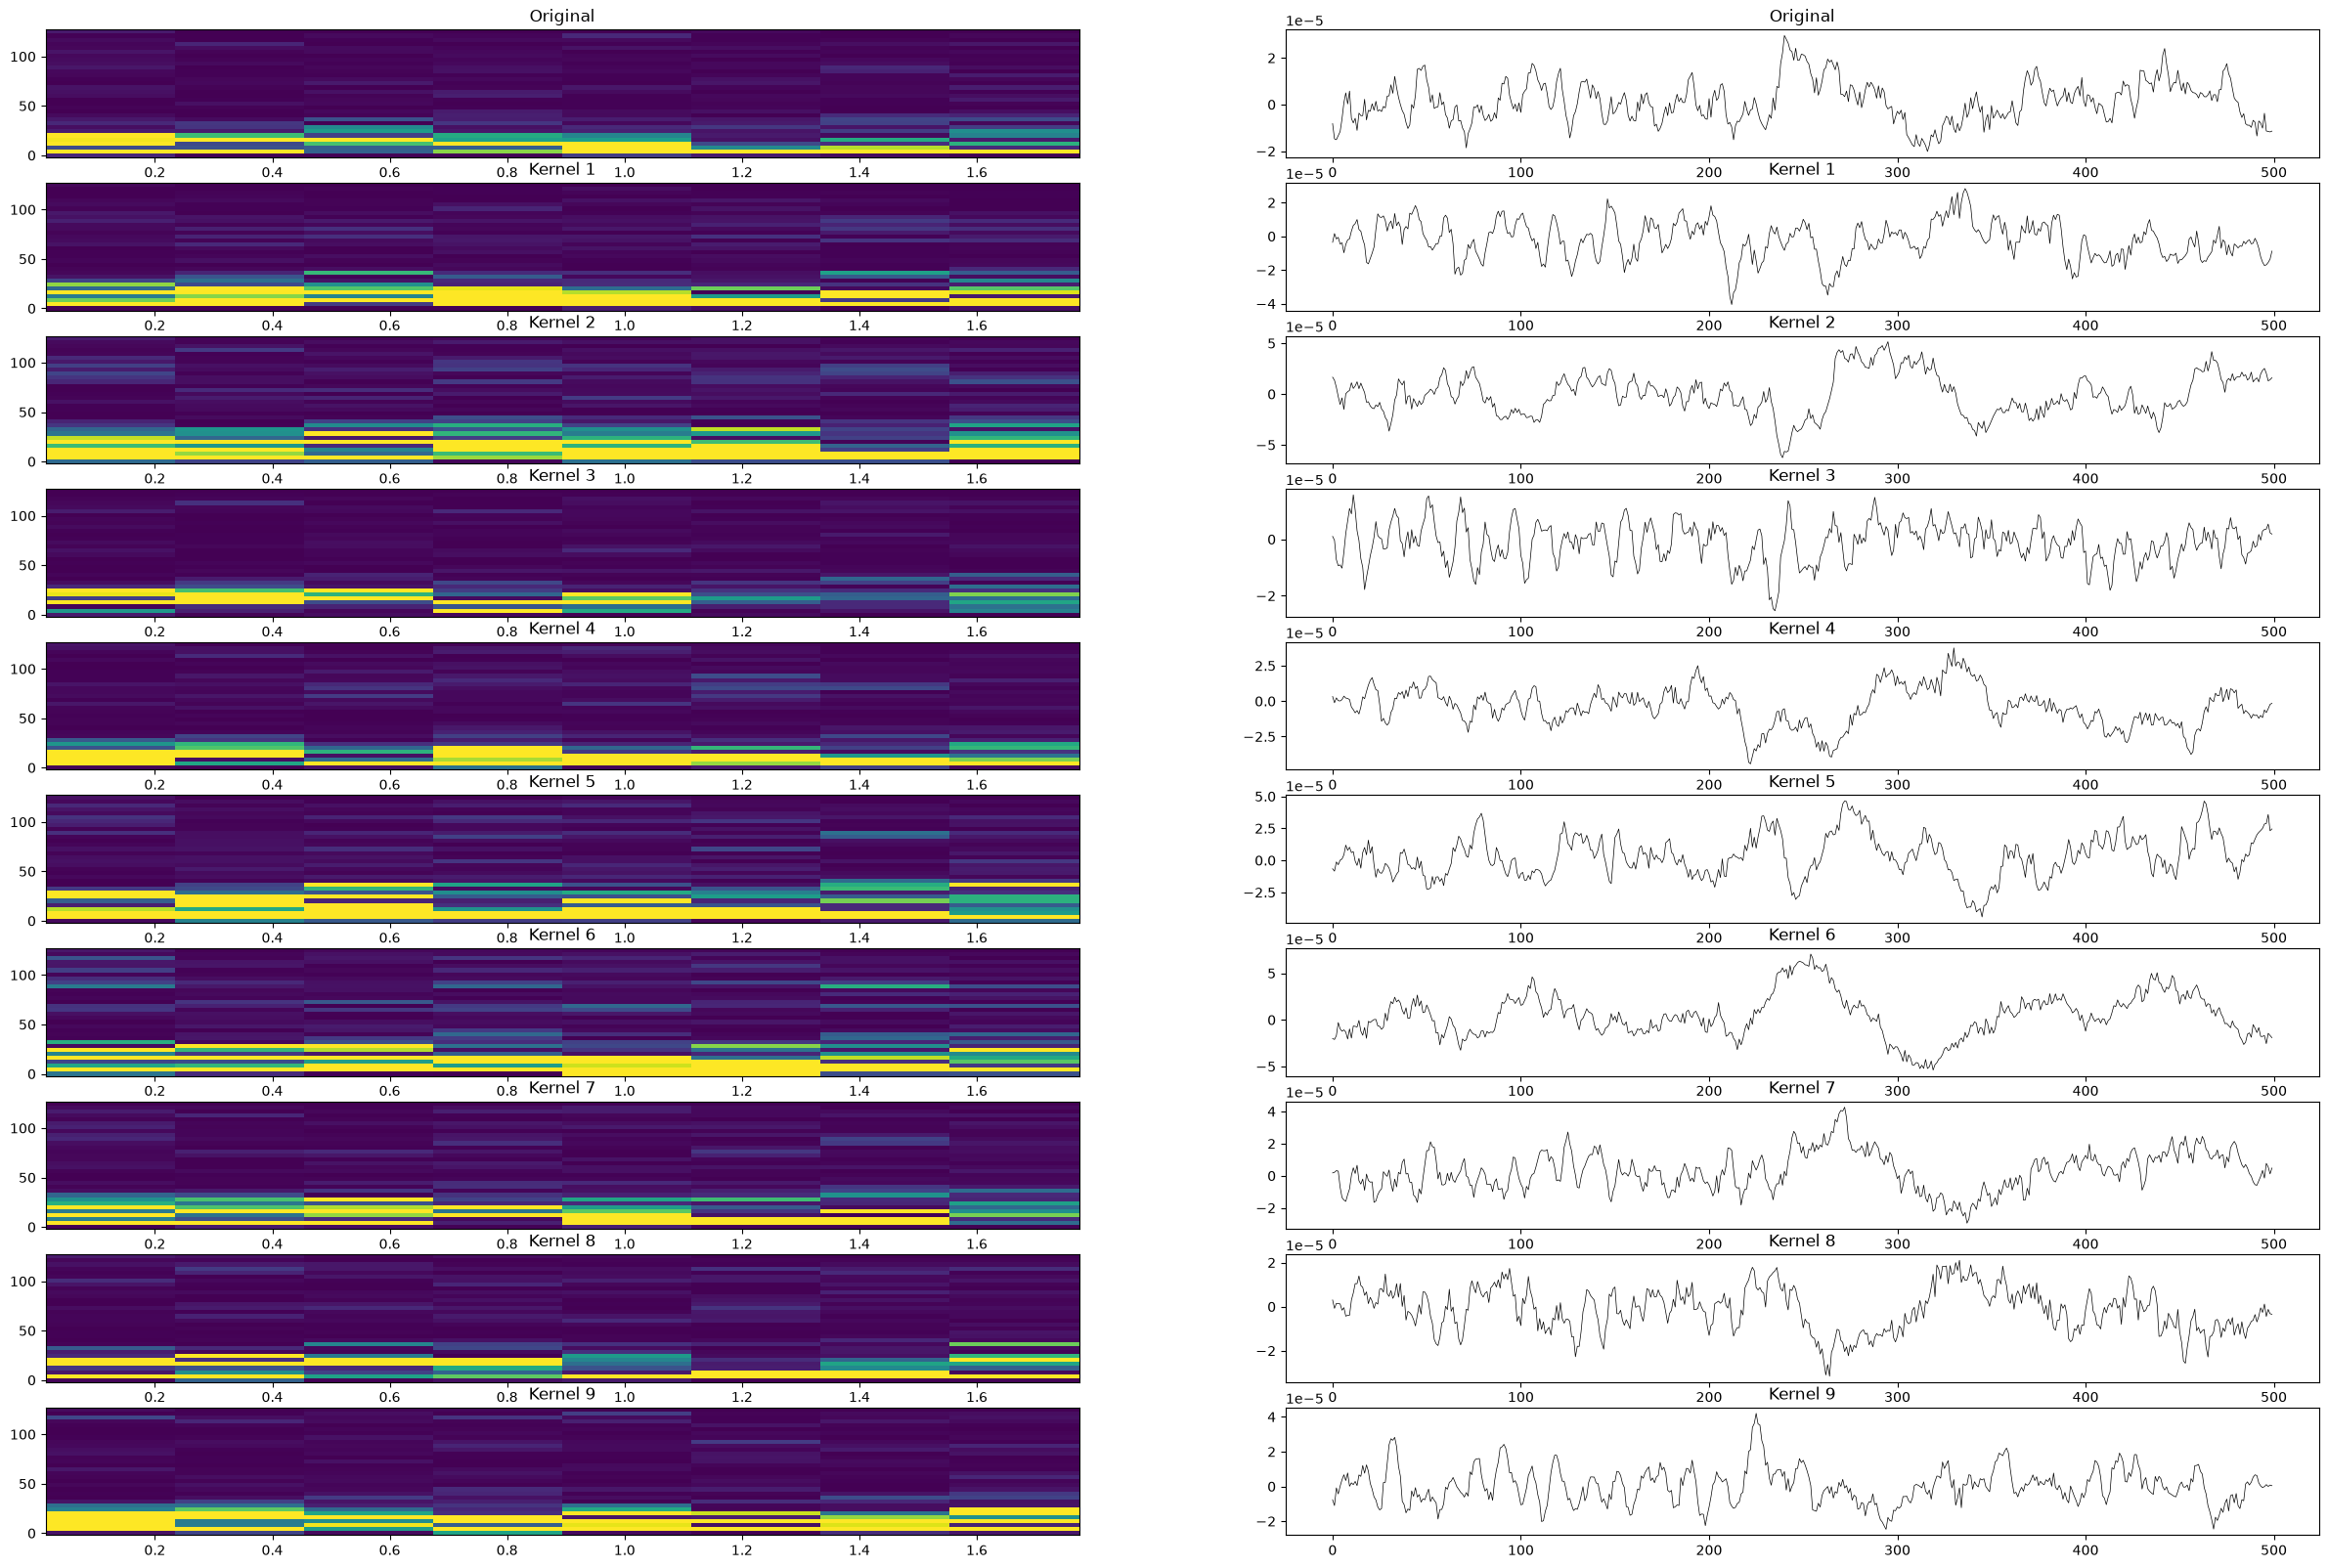

In [241]:
plot_end_results(final_kernels,data)